In [2]:
import numpy as np 
import pandas as pd 
import matplotlib as plt 
import backtrader as bt 
import datetime
import os.path
import sys
import pyfolio as pf
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

2025-12-26, (MA Period 25) Ending Value 1409.00
2025-12-26, (MA Period 26) Ending Value 1366.13
2025-12-26, (MA Period 27) Ending Value 1353.72
2025-12-26, (MA Period 28) Ending Value 1333.64
2025-12-26, (MA Period 29) Ending Value 1335.16
2025-12-26, (MA Period 30) Ending Value 1322.85


Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,4.65,2021-11-18,2022-07-18,2023-07-12,430
1,2.82,2015-03-02,2016-01-04,2017-10-11,683
2,2.81,2018-01-26,2019-01-14,2019-06-19,364
3,2.81,2025-10-29,2025-12-17,NaT,NaN
4,2.56,2024-07-16,2024-09-06,2024-10-09,62


Stress Events,mean,min,max
Fall2015,-0.01%,-0.28%,0.08%
New Normal,0.00%,-0.65%,0.41%
Covid,0.02%,-1.55%,1.72%


Top 10 long positions of all time,max
stocks,49.00%


Top 10 short positions of all time,max


...

PnL stats,All trades,Long trades
Total profit,$409.00,$409.00
Gross profit,$690.38,$690.38
Gross loss,$-281.38,$-281.38
Profit factor,$2.45,$2.45
Avg. trade net profit,$3.17,$3.17
Avg. winning trade,$13.81,$13.81
Avg. losing trade,$-3.56,$-3.56
Ratio Avg. Win:Avg. Loss,$3.88,$3.88
Largest winning trade,$82.62,$82.62
Largest losing trade,$-22.27,$-22.27


Duration stats,All trades,Long trades
Avg duration,21 days 07:15:20.937984581,21 days 07:15:20.937984581
Median duration,7 days 00:00:00,7 days 00:00:00
Longest duration,154 days 00:00:00,154 days 00:00:00
Shortest duration,1 days 00:00:00,1 days 00:00:00


Return stats,All trades,Long trades
Avg returns all round_trips,0.97%,0.97%
Avg returns winning,0.97%,0.97%
Avg returns losing,NaN,NaN
Median returns all round_trips,0.97%,0.97%
Median returns winning,0.97%,0.97%
Median returns losing,NaN,NaN
Largest winning trade,0.97%,0.97%
Largest losing trade,0.97%,0.97%


Symbol stats,stocks
Avg returns all round_trips,0.97%
Avg returns winning,0.97%
Avg returns losing,NaN
Median returns all round_trips,0.97%
Median returns winning,0.97%
Median returns losing,NaN
Largest winning trade,0.97%
Largest losing trade,0.97%


Profitability (PnL / PnL total) per name,
symbol,
stocks,100.00%


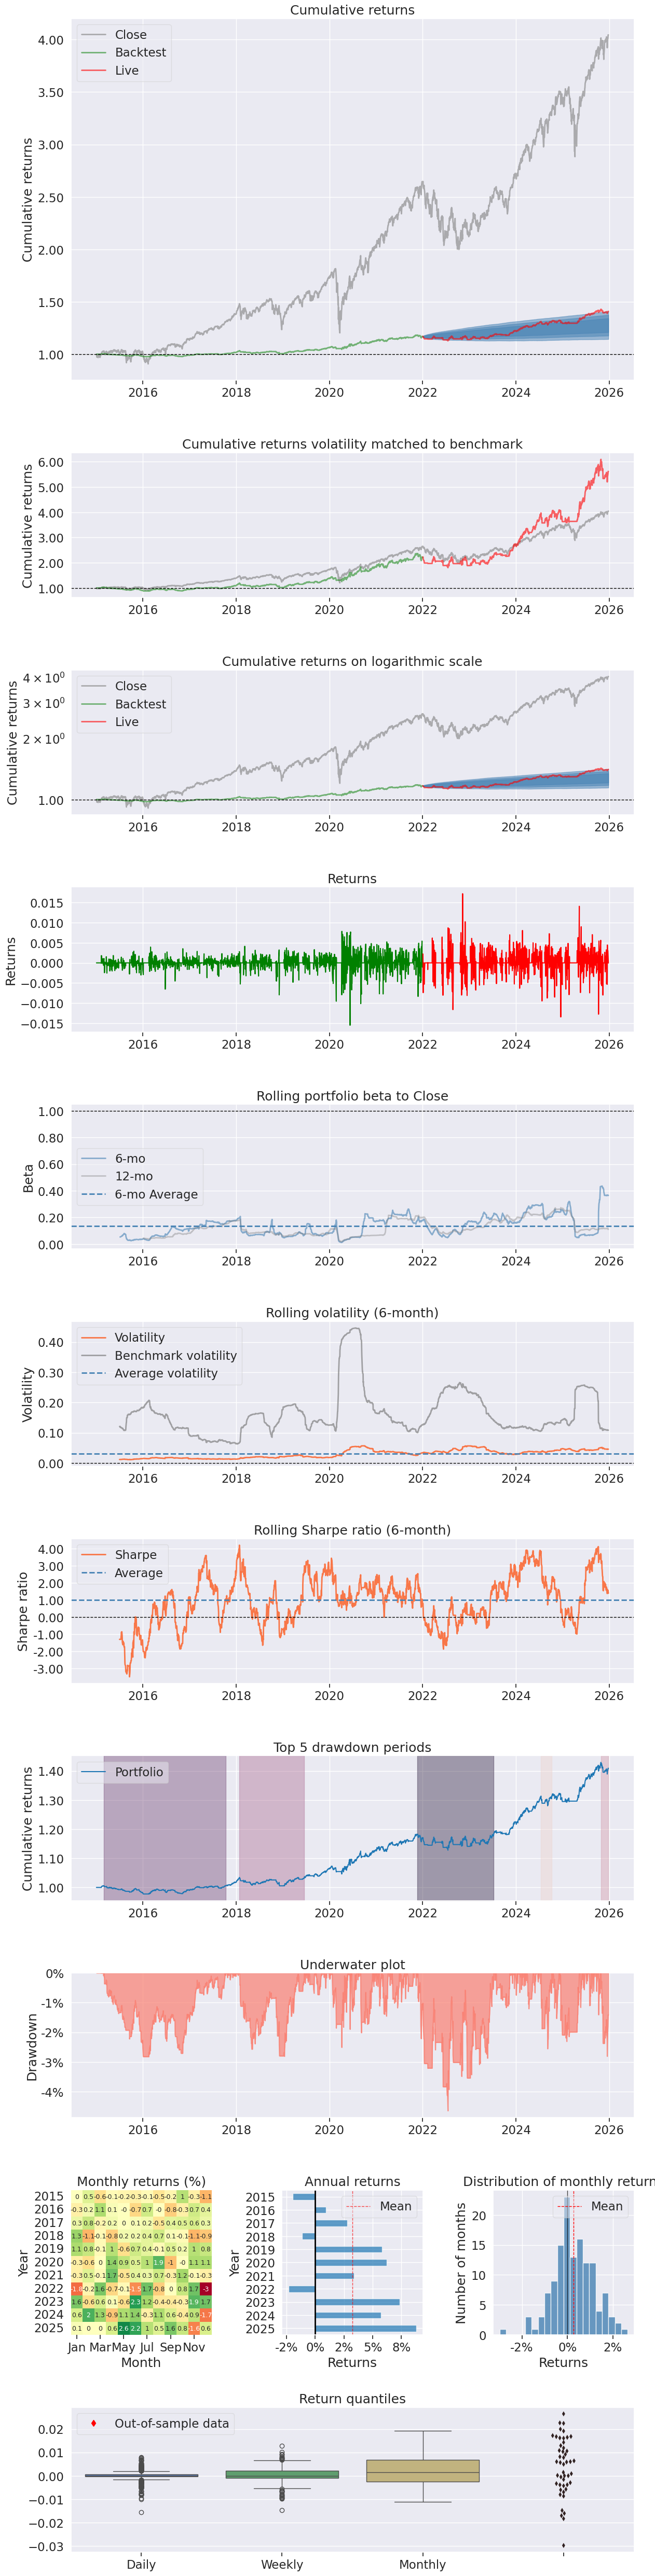

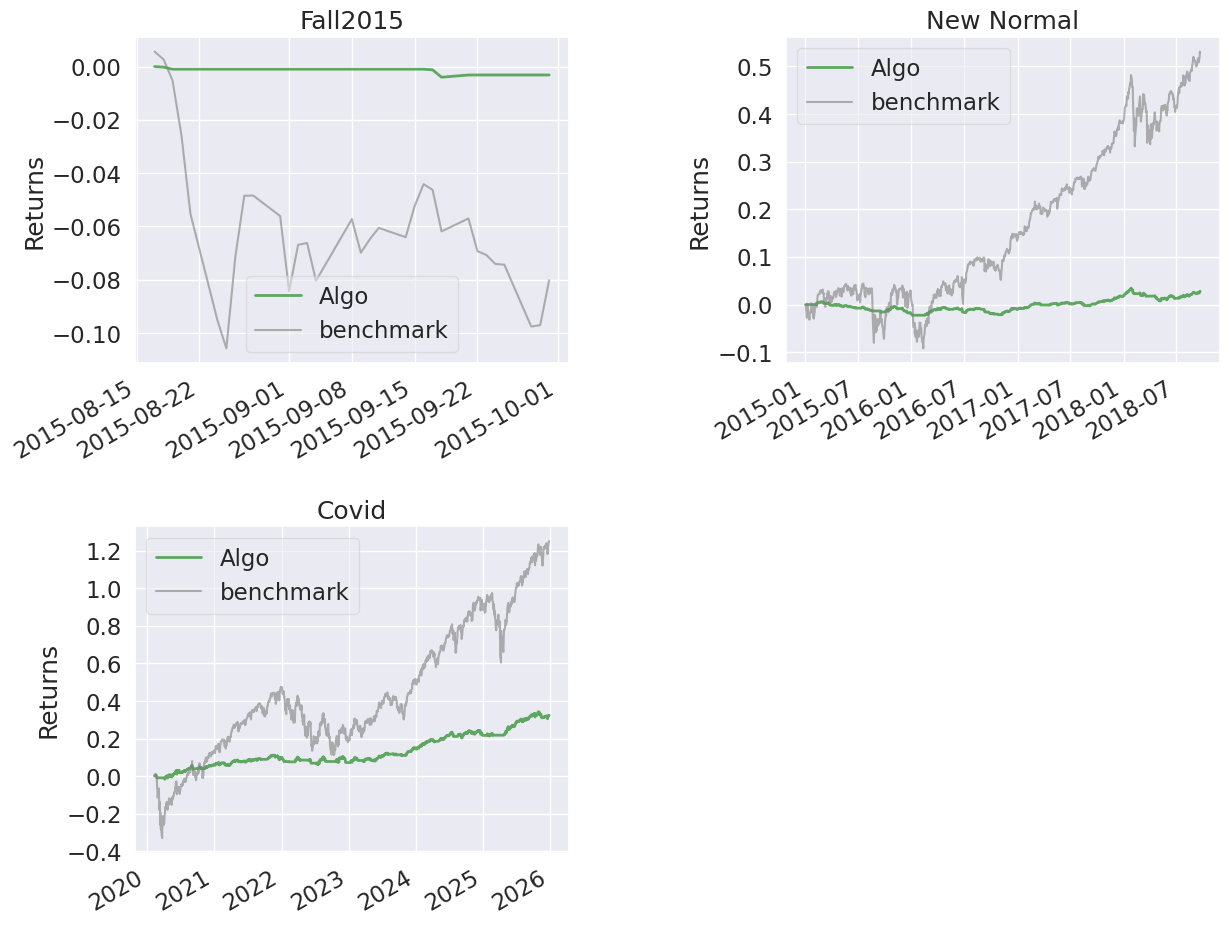

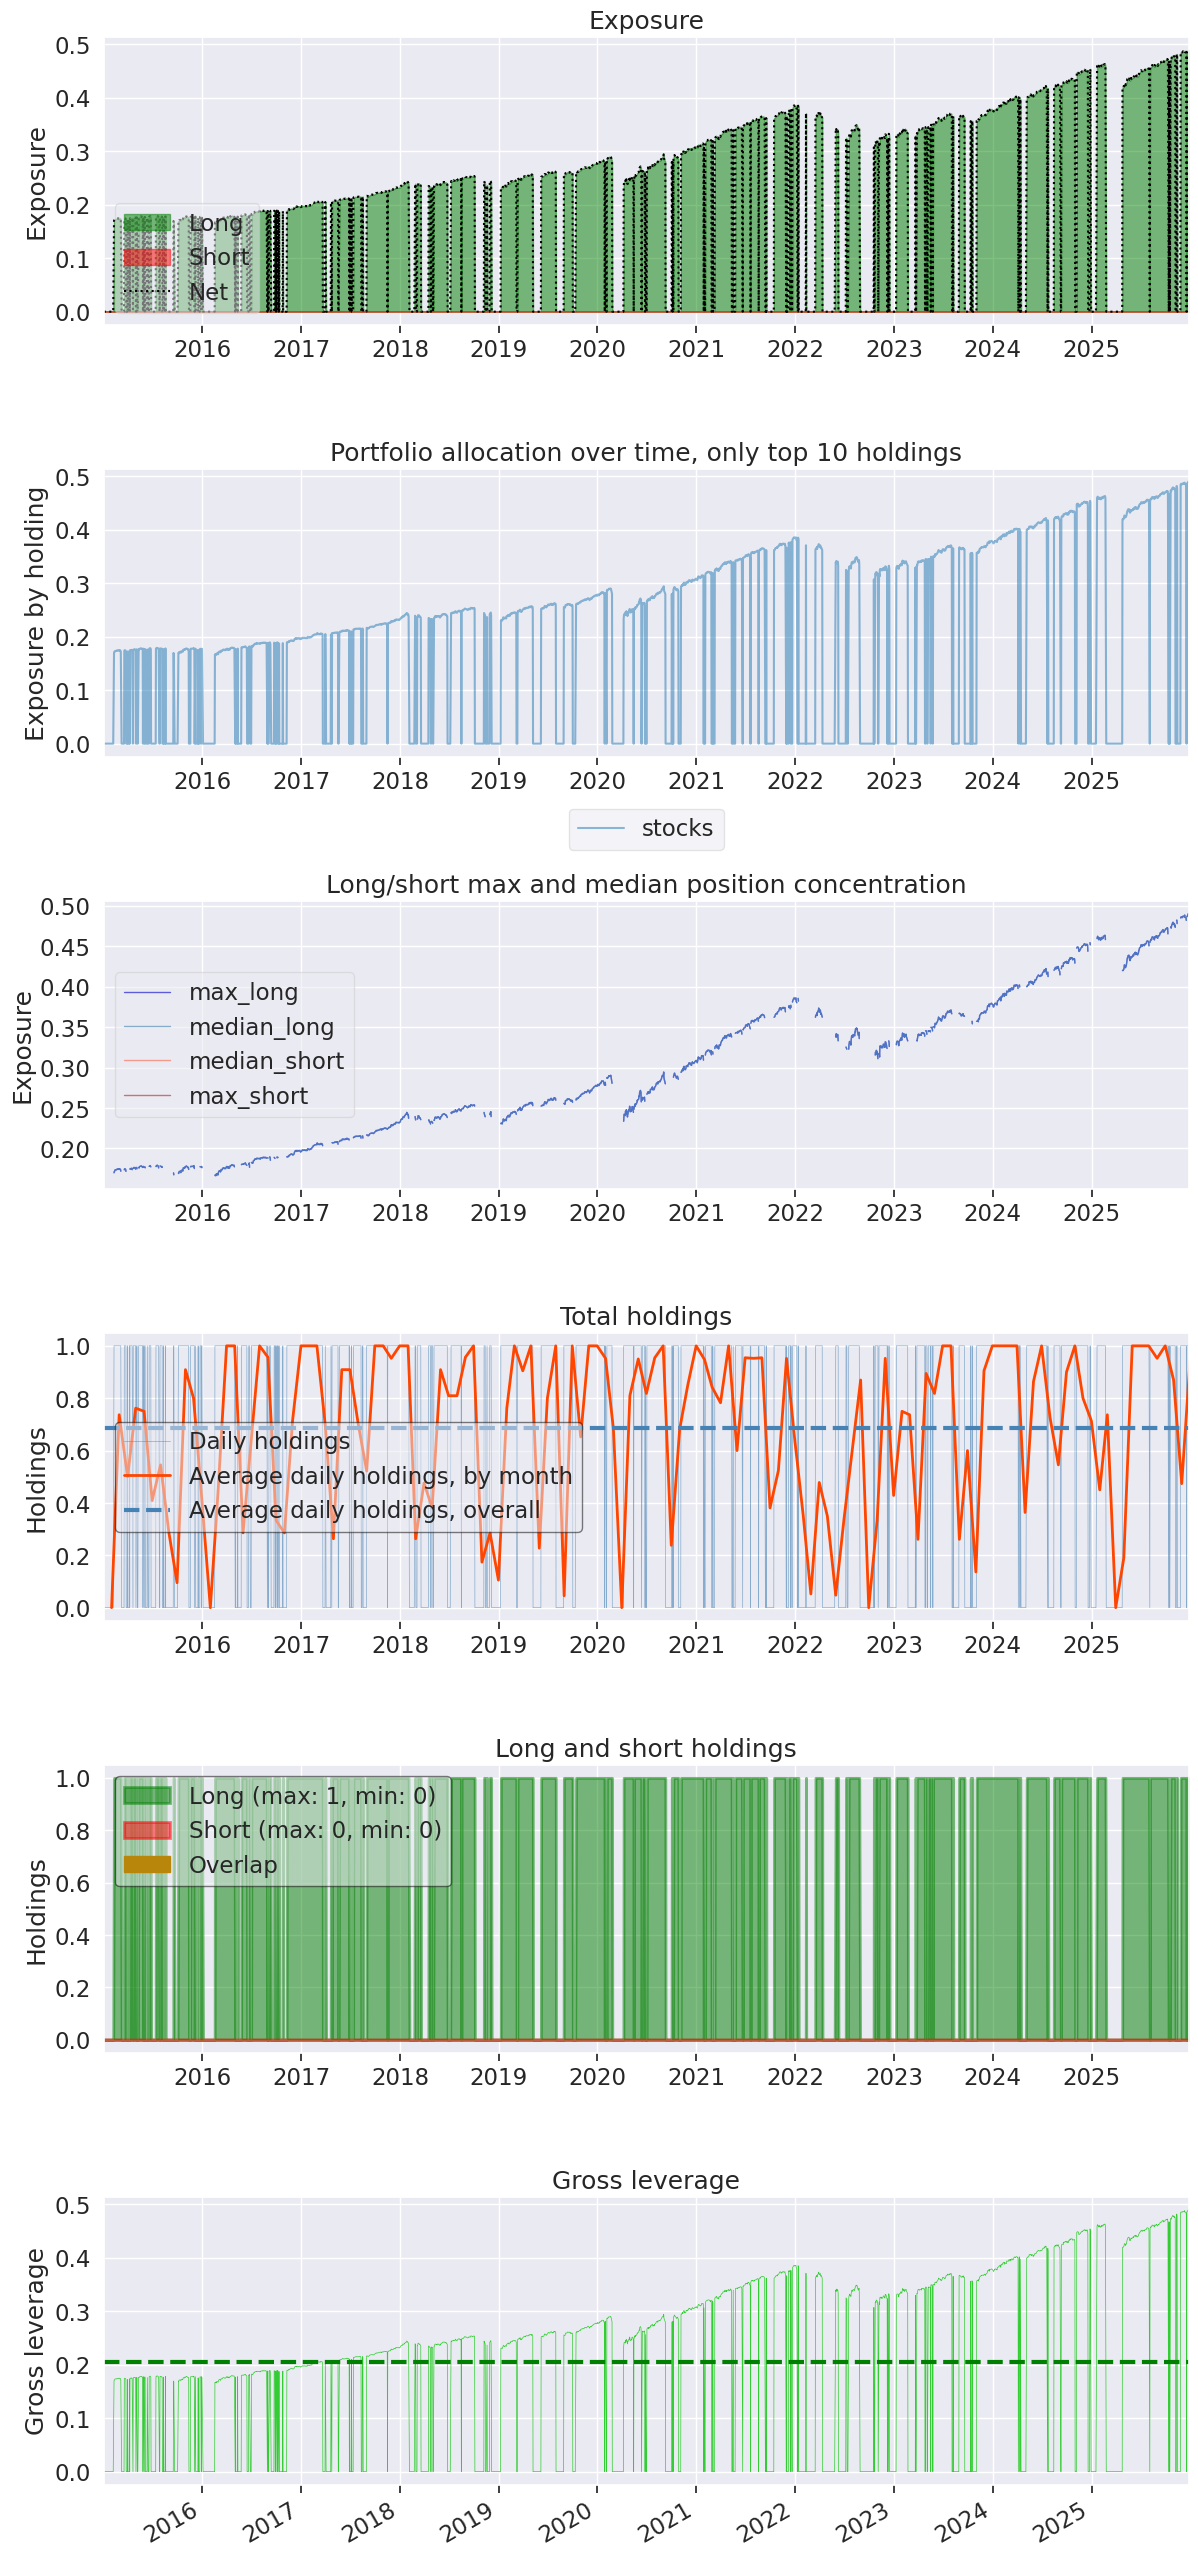

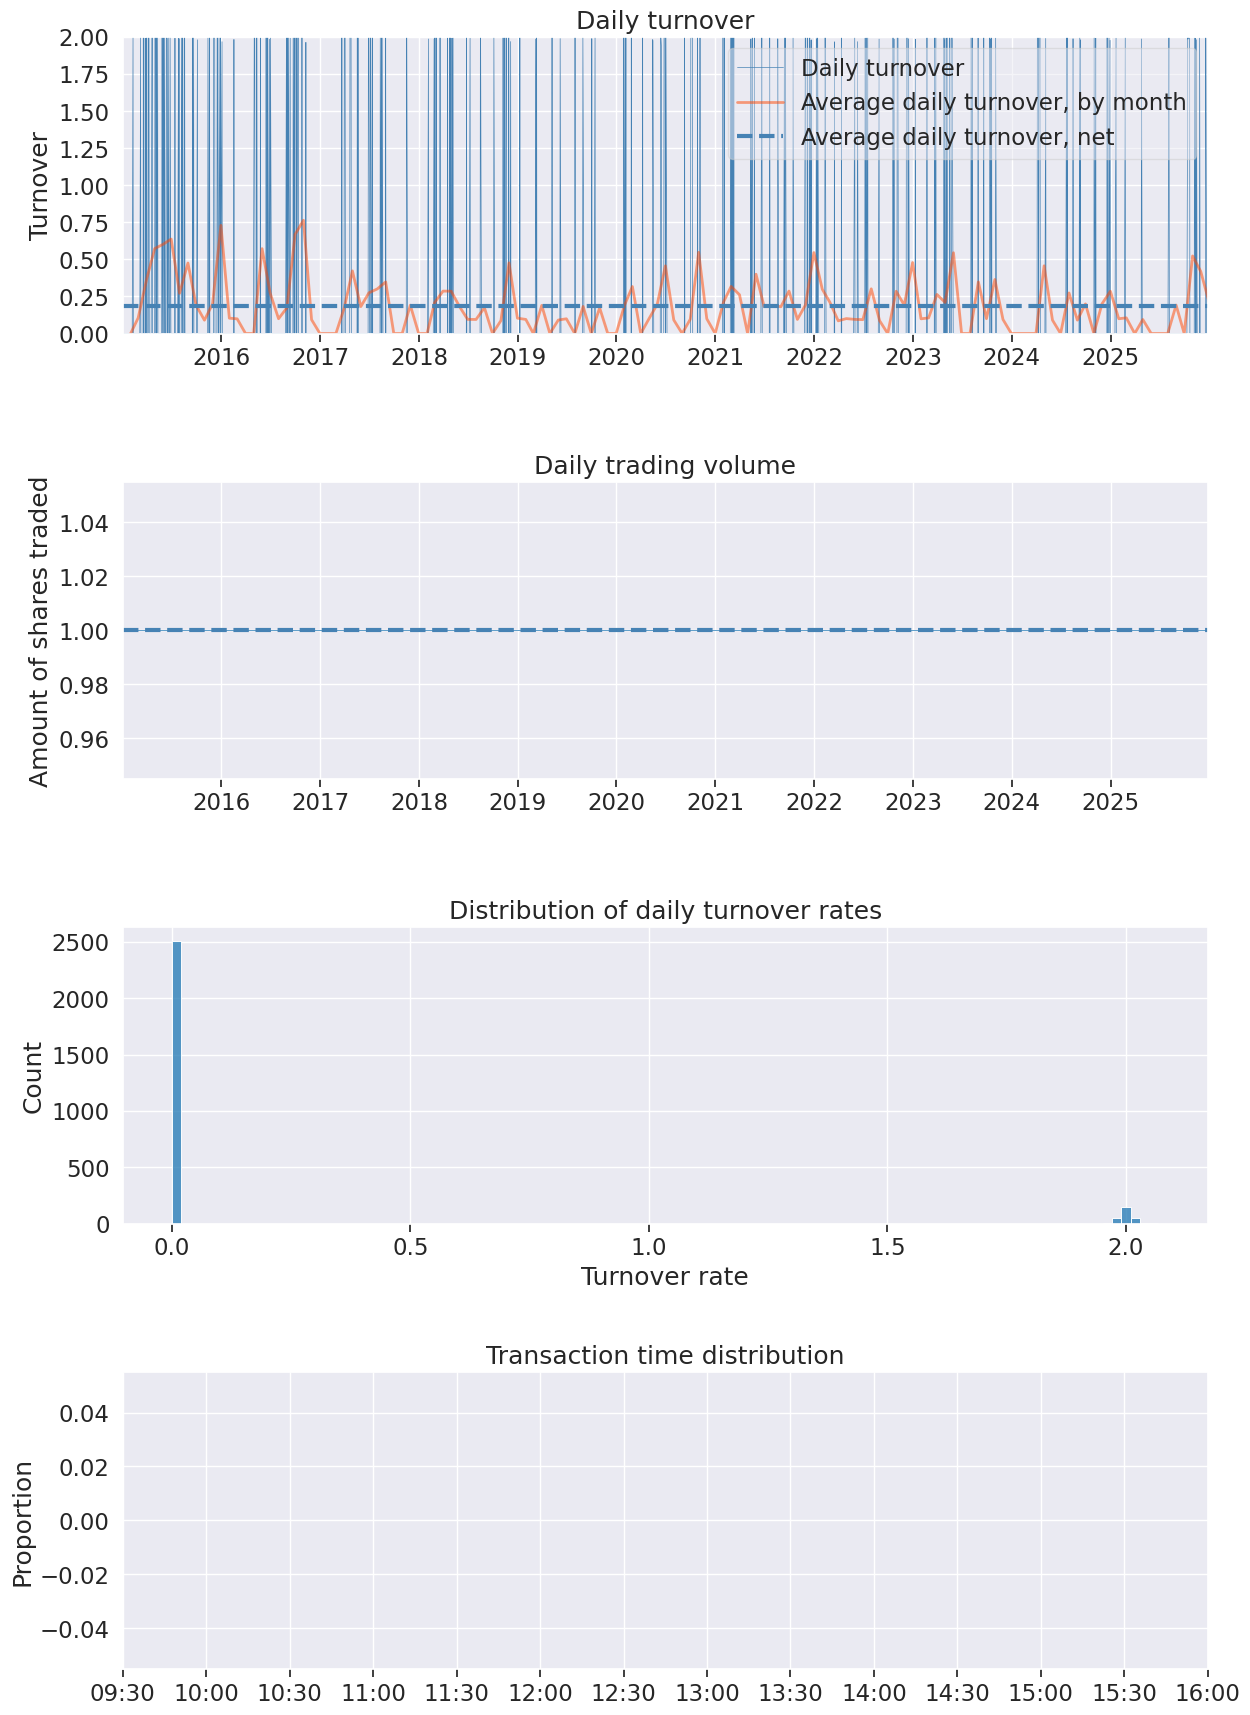

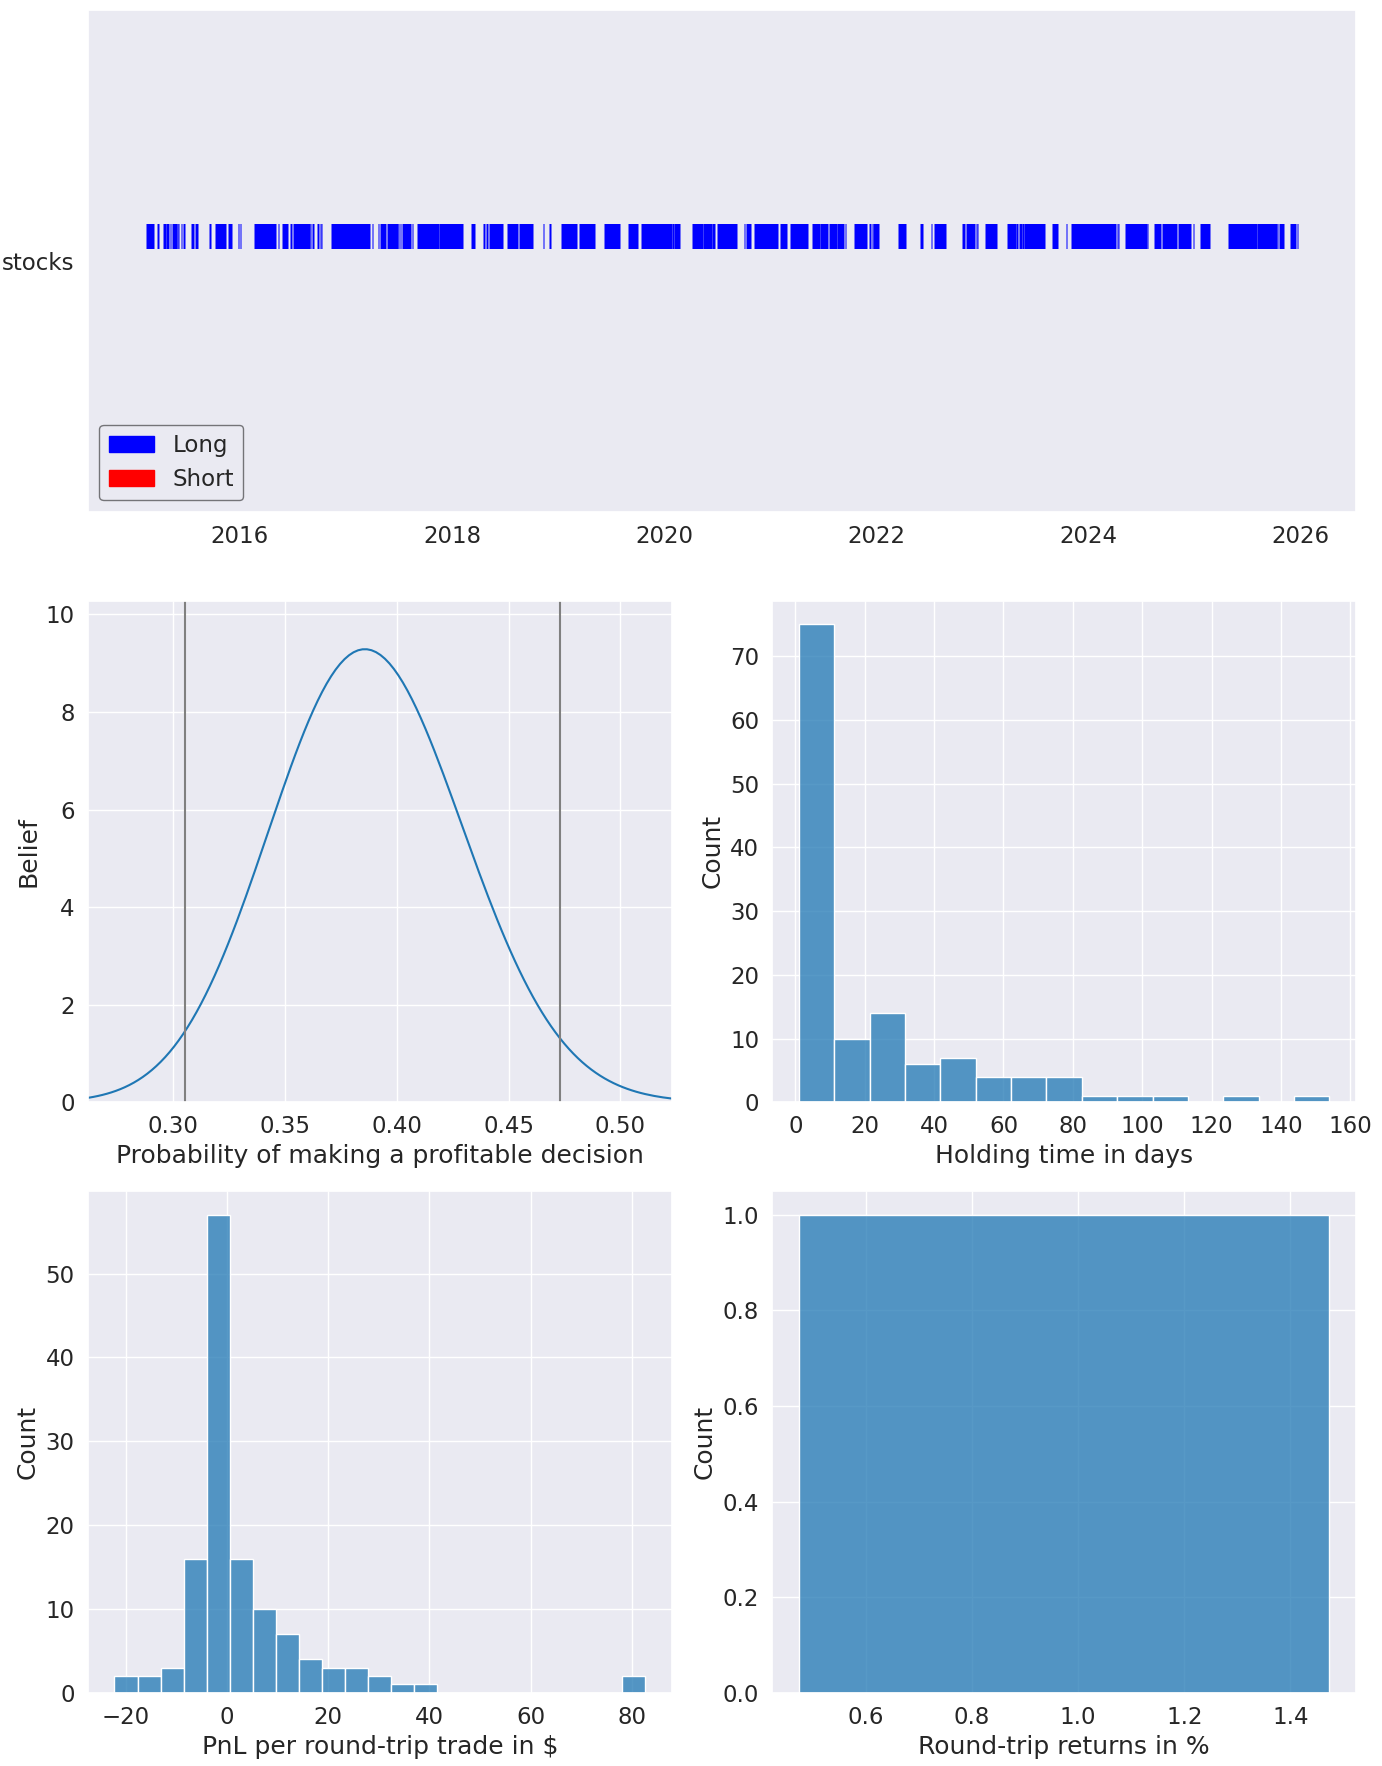

In [22]:
class TestStrategy(bt.Strategy):
    params = (
        ('maperiod', 30),
        ('printlog', False),
    )

    def log(self, txt, dt=None, doprint=False):
        ''' Logging function fot this strategy'''
        if self.params.printlog or doprint:
            dt = dt or self.datas[0].datetime.date(0)
            print('%s, %s' % (dt.isoformat(), txt))

    def __init__(self):
        # Keep a reference to the "close" line in the data[0] dataseries
        self.dataclose = self.datas[0].close

        # To keep track of pending orders and buy price/commission
        self.order = None
        self.buyprice = None
        self.buycomm = None

        # Add a MovingAverageSimple indicator
        self.sma = bt.indicators.SimpleMovingAverage(
            self.datas[0], period=self.params.maperiod)

    def notify_order(self, order):
        if order.status in [order.Submitted, order.Accepted]:
            # Buy/Sell order submitted/accepted to/by broker - Nothing to do
            return

        # Check if an order has been completed
        # Attention: broker could reject order if not enough cash
        if order.status in [order.Completed]:
            if order.isbuy():
                self.log(
                    'BUY EXECUTED, Price: %.2f, Cost: %.2f, Comm %.2f' %
                    (order.executed.price,
                     order.executed.value,
                     order.executed.comm))

                self.buyprice = order.executed.price
                self.buycomm = order.executed.comm
            else:  # Sell
                self.log('SELL EXECUTED, Price: %.2f, Cost: %.2f, Comm %.2f' %
                         (order.executed.price,
                          order.executed.value,
                          order.executed.comm))

            self.bar_executed = len(self)

        elif order.status in [order.Canceled, order.Margin, order.Rejected]:
            self.log('Order Canceled/Margin/Rejected')

        # Write down: no pending order
        self.order = None

    def notify_trade(self, trade):
        if not trade.isclosed:
            return

        self.log('OPERATION PROFIT, GROSS %.2f, NET %.2f' %
                 (trade.pnl, trade.pnlcomm))

    def next(self):
        # Simply log the closing price of the series from the reference
        self.log('Close, %.2f' % self.dataclose[0])

        # Check if an order is pending ... if yes, we cannot send a 2nd one
        if self.order:
            return

        # Check if we are in the market
        if not self.position:

            # Not yet ... we MIGHT BUY if ...
            if self.dataclose[0] > self.sma[0]:

                # BUY, BUY, BUY!!! (with all possible default parameters)
                self.log('BUY CREATE, %.2f' % self.dataclose[0])

                # Keep track of the created order to avoid a 2nd order
                self.order = self.buy()

        else:

            if self.dataclose[0] < self.sma[0]:
                # SELL, SELL, SELL!!! (with all possible default parameters)
                self.log('SELL CREATE, %.2f' % self.dataclose[0])

                # Keep track of the created order to avoid a 2nd order
                self.order = self.sell()

    def stop(self):
        self.log('(MA Period %2d) Ending Value %.2f' %
                 (self.params.maperiod, self.broker.getvalue()), doprint=True)
                



cerebro = bt.Cerebro()


# add strategy
strats = cerebro.optstrategy(TestStrategy, maperiod = range(25, 31))


# cerebro.addstrategy(TestStrategy)



data = bt.feeds.GenericCSVData(
    dataname = os.path.join('data', 'stocks.csv'),
    fromdate = datetime.datetime(2015,1,1),
    #todate = datetime.datetime(2025,12,27),
    reverse = False,
    dtformat='%Y-%m-%d %H:%M:%S%z',
    datetime=0,           # Date column
    open=1,               # Open column
    high=2,               # High column
    low=3,                # Low column
    close=4,              # Close column
    volume=5,             # Volume column
    openinterest=-1      # no openinterest column
)

cerebro.adddata(data)
cerebro.broker.setcash(1000.0)

#cerebro.addsizer(bt.sizers.PercentSizer, percents = 1)

cerebro.addsizer(bt.sizers.FixedSize, stake = 1)
cerebro.broker.setcommission(commission = 0)

cerebro.addanalyzer(bt.analyzers.PyFolio, _name = 'pyfolio')
strats = cerebro.run(maxcpus = 1)
strat = strats[0][0]

pyfoliozer = strat.analyzers.getbyname('pyfolio')
returns, positions, transactions, gross_lev = pyfoliozer.get_pf_items()

#print(cerebro.broker.getvalue())
#cerebro.plot()


data_path = os.path.join('data', 'stocks.csv')
benchmark_df = pd.read_csv(
    data_path,
    index_col=0,
    parse_dates=True,
    date_parser=lambda x: pd.to_datetime(x, utc=True) # Ensure datetime index is set and timezone aware
)
bench = benchmark_df.Close.pct_change().dropna()
bench.index = bench.index.normalize()
returns.index = returns.index.normalize()
if returns.index.tz is None:
    returns.index = returns.index.tz_localize('UTC')
else:
    returns.index = returns.index.tz_convert('UTC')
returns.index.name = None

common = returns.index.intersection(bench.index)
returns = returns.loc[common]
bench = bench.loc[common]

pf.create_full_tear_sheet(
    returns,
    positions=positions,
    transactions=transactions,
    #gross_lev=gross_lev,
    live_start_date='2022-01-01',  # This date is sample specific
    round_trips=True,
    benchmark_rets=bench)